<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment2/blob/main/ESAA_OB_WEEK5_study_0928.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##9.7 행렬 분해를 이용한 잠재 요인 협업 필터링 실습

* 사용자-아이템 평점 행렬의 Null 데이터를 고려해 SGD 기반 행렬 분해를 이용한 잠재 요인 협업 필터링을 구현함.
* 기존 확률적 경사 하강법 행렬 분해 예제의 `get_rmse()`를 활용하고, 행렬 분해 로직을 `matrix_factorization()` 함수로 정리함.
* `R`, 잠재 요인 차원 `K`, 반복 횟수 `steps`, 학습률 `learning_rate`, L2 규제 계수 `r_lambda`를 설정해 영화 추천에 활용함.


In [ ]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
  error = 0
  for i, j, r in non_zeros:
    pred = np.dot(P[i, :], Q[j, :].T)
    error += pow(r - pred, 2)
    rmse = np.sqrt(error / len(non_zeros))

  return rmse

In [ ]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda=0.01):
  num_users, num_items = R.shape
  # P와 Q 매트릭스의 크기를 지정하고 정규 분포를 가진 랜덤한 값으로 입력함.
  np.random.seed(1)
  P = np.random.normal(scale=1./K, size=(num_users, K))
  Q = np.random.normal(scale=1./K, size=(num_items, K))

  # R > 0인 행 위치, 열 위치, 값을 non_zeros 리스트 객체에 저장.
  non_zeros = [ (i, j, R[i, j]) for i in range(num_users) for j in range(num_items) if R[i, j] > 0 ]

  # SGD 기법으로 P와 Q 매트릭스를 계속 업데이트.
  for step in range(steps):
    for i, j, r in non_zeros:
      # 실제 값과 예측 값의 차이인 오류 값 구함
      eij = r - np.dot(P[i,:], Q[j,:].T)
      # Regularization을 반영한 SGD 업데이트 공식 적용
      P[i, :] = P[i, :] + learning_rate*(eij * Q[j, :] - r_lambda*P[i, :])
      Q[j, :] = Q[j, :] + learning_rate*(eij * P[i, :] - r_lambda*Q[j, :])

    rmse = get_rmse(R, P, Q, non_zeros)
    if (step % 10) == 0:
      print("### iteration step: ", step, "rmse: ", rmse)

  return P, Q

In [ ]:
import pandas as pd
import numpy as np

movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index='userId', columns='movieId')

# title 칼럼을 얻기 위해 movies와 조인 수행
rating_movies = pd.merge(ratings, movies, on='movieId')
# columns='title'로 title 칼럼으로 pivot 수행.
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')

In [ ]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01,
                            r_lambda = 0.01)
pred_matrix = np.dot(P, Q.T)

### iteration step:  0 rmse:  2.9023619751337115
### iteration step:  10 rmse:  0.7335768591017939
### iteration step:  20 rmse:  0.5115539026853438
### iteration step:  30 rmse:  0.37261628282537734
### iteration step:  40 rmse:  0.29608182991810145
### iteration step:  50 rmse:  0.2520353192341621
### iteration step:  60 rmse:  0.22487503275269882
### iteration step:  70 rmse:  0.20685455302331512
### iteration step:  80 rmse:  0.19413418783028674
### iteration step:  90 rmse:  0.1847008200272031
### iteration step:  100 rmse:  0.17742927527209082
### iteration step:  110 rmse:  0.17165226964707506
### iteration step:  120 rmse:  0.16695181946871496
### iteration step:  130 rmse:  0.16305292191997453
### iteration step:  140 rmse:  0.159766919296796
### iteration step:  150 rmse:  0.15695986999457337
### iteration step:  160 rmse:  0.15453398186715442
### iteration step:  170 rmse:  0.1524161855107769
### iteration step:  180 rmse:  0.1505508073962834
### iteration step:  190 rmse:  

In [ ]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index=ratings_matrix.index,
                                   columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


In [ ]:
# 사용자 9번 영화추천

def get_unseen_movies(ratings_matrix, userId):
  # userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환함.
  # 반환된 user_rating은 영화명(title)을 인덱스를 가지는 Series 객체임.
  user_rating = ratings_matrix.loc[userId, :]
  # user_rating이 0보다 크면 기존에 관람한 영화임. 대상 인덱스를 추출해 list 객체로 만듦.
  already_seen = user_rating[ user_rating > 0].index.tolist()

  # 모든 영화명을 list 객체로 만듦.
  movies_list = ratings_matrix.columns.tolist()
  # list comporehension으로 already_seen에 해당하는 영화는 movies_list에서 제외함.
  unseen_list = [ movie for movie in movies_list if movie not in already_seen]

  return unseen_list

def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n = 10):
  # 예측 평점 DataFrame에서 사용자id 인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해
  # 가장 예측 평점이 높은 순으로 정렬함.
  recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
  return recomm_movies

In [ ]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이터를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index,
                             columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


##9.8 파이썬 추천 시스템 패키지 - Surprise

###Surprise 패키지 소개

In [1]:
! pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.0 MB/s eta 0:00:00


In [ ]:
! conda install -c conda-forge scikit-surprise

/bin/bash: line 1: conda: command not found


In [ ]:
!pip install numpy
!pip install scikit-surprise --upgrade --no-deps

###Surprise를 이용한 추천 시스템 구축

In [2]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

In [3]:
data = Dataset.load_builtin('ml-100k')
# 수행 시마다 동일하게 데이터를 분할하기 위해 random_state 값 부여
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


* Surprise의 `ml-100k` 데이터는 한 번 저장하면 로컬에서 다시 불러올 수 있으며, 과거 버전이라 최신 `ratings.csv`와 데이터 형식이 다름.
* Surprise는 사용자-아이템 평점 행렬이 아닌 로우 레벨의 원본 평점 데이터를 입력으로 받아 자체적으로 행렬 형태로 변환함.
* `SVD()` 객체를 생성한 뒤 `fit()`으로 학습 데이터를 학습시켜 잠재 요인 협업 필터링 기반 추천을 수행함.


In [4]:
algo = SVD(random_state=0)
algo.fit(trainset)

In [5]:
predictions = algo.test(testset)
print('prediction type :', type(predictions), ' size:', len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type : <class 'list'>  size: 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=np.float64(3.5114147666251547), details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=np.float64(3.573872419581491), details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=np.float64(4.033583485472447), details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=np.float64(3.8463639495936905), details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=np.float64(3.1807542478219157), details={'was_impossible': False})]

* SVD의 `test()`는 테스트 데이터 크기와 같은 25,000개의 `Prediction` 객체를 리스트로 반환함.
* 각 `Prediction` 객체에는 사용자 ID(`uid`), 영화 ID(`iid`), 실제 평점(`r_ui`), 예측 평점(`est`) 등의 정보가 포함됨.
* `was_impossible`이 `True`이면 예측이 불가능했다는 의미이며, 여기서는 모두 `False`이고 객체명.속성명으로 각 정보를 확인할 수 있음.


In [6]:
[ (pred.uid, pred.iid, pred.est) for pred in predictions[:3] ]

[('120', '282', np.float64(3.5114147666251547)),
 ('882', '291', np.float64(3.573872419581491)),
 ('535', '507', np.float64(4.033583485472447))]

In [7]:
# 사용자 아이디, 아이템 아이디는 문자열로 입력해야 함.
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


In [8]:
accuracy.rmse(predictions)

RMSE: 0.9467


np.float64(0.9466860806937948)

###Surprise 주요 모듈 소개

####Dataset
* Surprise는 사용자 ID, 아이템 ID, 평점이 로우 단위로 구성된 데이터만 입력할 수 있음.
* 기본적으로 첫 3개 칼럼만 사용자 ID·아이템 ID·평점으로 읽고, 네 번째 칼럼부터는 제외함.
* 파일뿐 아니라 Pandas DataFrame도 사용할 수 있으며, 칼럼 순서는 반드시 사용자 ID → 아이템 ID → 평점이어야 함.

* `Dataset.load_builtin()`
  - MovieLens 아카이브 FTP 서버에서 `ml-100k` 또는 `ml-1m` 데이터를 내려받음.
  * 처음 내려받은 데이터는 `.surprise_data` 디렉터리에 저장되며, 이후에는 저장된 데이터를 재사용함.
  * `name`으로 데이터셋을 지정하고 기본값은 `ml-100k`임.
* `Dataset.load_from_file()`
  - 콤마·탭 등으로 구분된 파일에서 데이터를 불러오며, 파일 경로와 `Reader`를 지정함.
* `Dataset.load_from_df()`
  - Pandas DataFrame에서 데이터를 불러오며, 반드시 3개 칼럼을 사용함.
  * 데이터 순서는 사용자 ID → 아이템 ID → 평점이어야 하며, `Reader`로 평점 데이터 형식을 지정함.


####OS 파일 데이터를 Surprise 데이터 세트로 로딩

In [9]:
import pandas as pd

ratings = pd.read_csv('ratings.csv')
# ratings_noh.csv 파일로 언로드 시 인덱스와 헤더를 모두 제거한 새로운 파일 생성.
ratings.to_csv('ratings_noh.csv', index=False, header=False)

In [10]:
from surprise import Reader

reader = Reader(line_format = 'user item rating timestamp', sep=',', rating_scale=(0.5, 5))
data = Dataset.load_from_file('ratings_noh.csv', reader=reader)

SVD 행렬 분해 기법을 이용해 추천 예측

In [11]:
trainset, testset = train_test_split(data, test_size=25, random_state=0)

# 수행 시마다 동일한 결과를 도출하기 위해 random_state 설정
algo = SVD(n_factors=50, random_state=0)

# 학습 데이터 세트로 학습하고 나서 테스트 데이터 세트로 평점 예측 후 RMSE 평가
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.7940


np.float64(0.7939608260279409)

####판다스 DataFrame에서 Surprise 데이터 세트로 로딩

In [14]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('ratings.csv')
reader = Reader(rating_scale=(0.5, 5.0))

# ratings DataFrame에서 칼럼은 사용자 아이디, 아이템 아이디, 평점 순서를 지켜야 합니다.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
trainset, testset = train_test_split(data, test_size=25, random_state=0)

algo = SVD(n_factors=50, random_state=0)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.7940


np.float64(0.7939608260279409)

###Surprise 추천 알고리즘 클래스
- SVD
  - 행렬 분해를 통한 잠재 요인 협업 필터링을 위한 SVD 알고리즘
- KNNBasic
  - 최근접 이웃 협업 필터링을 위한 KNN 알고리즘
- BaselineOnly
  - 사용자 Bias와 아이템 Bias를 감안한 SGD 베이스라인 알고리즘

####입력 파라미터
- n_factors
  - 잠재요인 K의 개수
- n_epochs
  - SGD 수행 시 반복 횟수. 디폴트는 20.
- biased (bool)
  - 베이스라인 사용자 편향 적용 여부. 디폴트는 True.

---
* SVD++가 RMSE·MAE 성능은 가장 좋지만 연산 시간이 길어 데이터가 커지면 사용하기 어려움.
* SVD와 k-NN Baseline은 비교적 좋은 성능을 보이며, 특히 Baseline을 결합하면 k-NN의 성능이 크게 향상됨.
* Baseline은 사용자마다 다른 평점 부여 성향을 반영해 예측 평점을 보정하는 방식임.


###베이스라인 평점
* 같은 세미나나 영화라도 사람마다 평가 성향이 달라 평점에 개인별 편향이 발생할 수 있음.
* 이러한 사용자와 아이템의 편향을 반영해 평점을 예측하는 것을 베이스라인 평점이라고 함.
* 베이스라인 평점은 일반적으로 전체 평균 평점 + 사용자 편향 점수 + 아이템 편향 점수로 계산함.
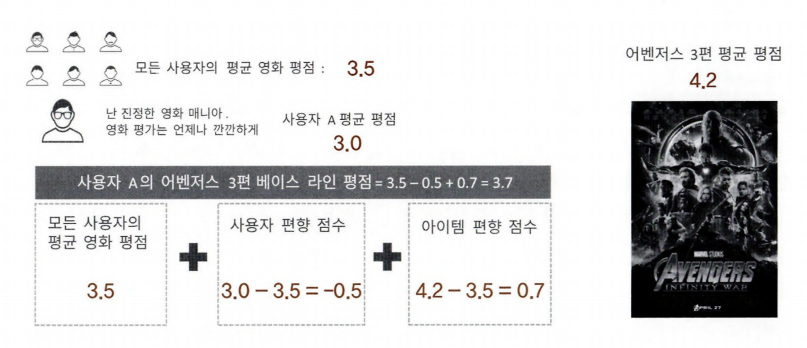


###교차 검증과 하이퍼 파라미터 튜닝

* Surprise는 `cross_validate()`와 `GridSearchCV`를 제공해 교차 검증과 하이퍼파라미터 튜닝을 지원함.
* `cross_validate()`는 데이터를 여러 학습·검증 폴드로 나누어 알고리즘의 성능을 평가함.
* 알고리즘 객체, 데이터, 평가 지표(RMSE·MAE), 폴드 수(`cv`) 등을 지정해 교차 검증을 수행함.


In [16]:
from surprise.model_selection import cross_validate

# 판다스 DataFrame에서 Surprise 데이터 세트로 데이터 로딩
ratings = pd.read_csv('ratings.csv') # reading data in pandas df
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

algo = SVD(random_state=0)
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8775  0.8728  0.8761  0.8664  0.8745  0.8734  0.0039  
MAE (testset)     0.6751  0.6721  0.6718  0.6672  0.6721  0.6717  0.0025  
Fit time          1.45    0.93    0.92    0.93    0.94    1.03    0.21    
Test time         0.08    0.08    0.08    0.18    0.08    0.10    0.04    


{'test_rmse': array([0.87747417, 0.87276927, 0.87606253, 0.86640475, 0.87450424]),
 'test_mae': array([0.6750964 , 0.67208655, 0.67182812, 0.66720388, 0.67211678]),
 'fit_time': (1.452397346496582,
  0.9272148609161377,
  0.9180078506469727,
  0.9333899021148682,
  0.9374604225158691),
 'test_time': (0.07661056518554688,
  0.07514715194702148,
  0.07925963401794434,
  0.1807105541229248,
  0.07647299766540527)}

In [17]:
from surprise.model_selection import GridSearchCV

# 최적화할 파라미터를 딕셔너리 형태로 지정.
param_grid = {'n_epochs': [20, 40, 60], 'n_factors': [50, 100, 200] }

# CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

# 최고 RMSE Evaluation 점수와 그때의 하이퍼 파라미터
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8773391328886128
{'n_epochs': 20, 'n_factors': 50}


###Surprise를 이용한 개인화 영화 추천 시스템 구축

* Surprise로 학습한 잠재 요인 협업 필터링 알고리즘을 이용해 사용자가 보지 않은 영화 중 개인 취향에 맞는 영화를 추천함.
* 이번에는 데이터를 학습·테스트로 나누지 않고 `ratings.csv` 전체를 학습 데이터로 사용함.
* Surprise의 `fit()`은 `TrainSet` 객체가 필요하므로 원본 데이터셋을 그대로 `fit()`에 입력하면 오류가 발생함.


In [ ]:
# 다음 코드는 train_test_split()으로 분리되지 않는 데이터 세트에 fit()을 호출해 오류가 발생합니다.
#data = Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)
#algo = SVD(n_factors=50, random_state=0)
#algo.fit(data)

* `cross_validate()`는 각 폴드의 성능과 전체 폴드의 평균 성능을 함께 출력하며, 데이터 분할에 따라 결과가 조금씩 달라질 수 있음.
* Surprise의 `GridSearchCV`는 교차 검증을 통해 최적의 하이퍼파라미터 조합을 탐색함.
* SVD에서는 주로 `n_epochs`(반복 횟수)와 `n_factors`(잠재 요인 수)를 조정하며 최적 조합을 찾음.


In [18]:
from surprise.model_selection import GridSearchCV

# 최적화할 파라미터를 딕셔너리 형태로 지정.
param_grid = {'n_epochs': [20, 40, 60], 'n_factors': [50, 100, 200] }

# CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

# 최고 RMSE Evaluation 점수와 그때의 하이퍼 파라미터
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8771578236543148
{'n_epochs': 20, 'n_factors': 50}


In [19]:
algo= SVD(n_epochs=20, n_factors=50, random_state=0)
algo.fit(trainset)

In [20]:
# 영화에 대한 상세 속성 정보 DataFrame 로딩
movies = pd.read_csv('movies.csv')

# userID=9의 movieId 데이터를 추출해 movieId=42 데이터가 있는지 확인.
movieIds = ratings[ratings['userId']==9]['movieId']
if movieIds[movieIds==42].count() ==0:
  print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


In [21]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.50   {'was_impossible': False}


In [22]:
def get_unseen_surprise(ratings, movies, userId):
  # 입력값으로 들어온 userId에 해당하는 사용자가 평점을 매긴 모든 영화를 리스트로 생성
  seen_movies = ratings[ratings['userId'] == userId]['movieId'].tolist()

  # 모든 영화의 movieId를 리스트로 생성.
  total_movies = movies['movieId'].tolist()

  # 모든 영화의 movieId 중 이미 평점을 매긴 영화의 movieId를 제외한 후 리스트로 생성
  unseen_movies = [movie for movie in total_movies if movie not in seen_movies]
  print('평점 매긴 영화 수:', len(seen_movies), '추천 대상 영화 수:', len(unseen_movies),
        '전체 영화 수:', len(total_movies))

  return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742


* 사용자 9번은 9,742개 영화 중 46개만 평가해 9,696개 영화를 추천 대상으로 설정함.
* SVD의 `predict()`로 모든 추천 대상 영화의 예상 평점을 계산하고, 예측 평점이 높은 순으로 정렬함.
* `recomm_movie_by_surprise()` 함수로 상위 N개 영화의 영화 ID·제목·예측 평점을 추출해 추천함.


In [23]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):

  # 알고리즘 객체의 predict() 메서드를 평점이 없는 영화에 반복 수행한 후 결과를 list 객체로 저장
  predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]

  # predictions list 객체는 surprise의 Predictions 객체를 원소로 가지고 있음.
  # [Prediction(uid='9', iid='1', est=3.69), Prediction(uid='9', iid='2', est=2.98),,,,]

  # 이를 est 값으로 정렬하기 위해서 아래의 sortkey_est 함수를 정의함.
  # sortkey_est 함수는 list 객체의 sort() 함수의 키 값으로 사용되어 정렬 수행.
  def sortkey_est(pred):
    return pred.est

  # sortkey_est() 반환값의 내림차순으로 정렬 수행하고 top_n개의 최상위 값 추출.
  predictions.sort(key=sortkey_est, reverse=True)
  top_predictions=predictions[:top_n]

  # top_n 으로 추출된 영화의 정보 추출. 영화 아이디, 추천 예상 평점, 제목 추출
  top_movie_ids = [int(pred.iid) for pred in top_predictions]
  top_movie_rating = [ pred.est for pred in top_predictions]
  top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']

  top_movie_preds = [ (id, title, rating) for id, title, rating in
                      zip(top_movie_ids, top_movie_titles, top_movie_rating)]

  return top_movie_preds

unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, top_n=10)

print('##### Top-10 추천 영화 리스트 #####')
for top_movie in top_movie_preds:
  print(top_movie[1], ":", top_movie[2])

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742
##### Top-10 추천 영화 리스트 #####
Toy Story (1995) : 3.5014879328644692
Jumanji (1995) : 3.5014879328644692
Grumpier Old Men (1995) : 3.5014879328644692
Waiting to Exhale (1995) : 3.5014879328644692
Father of the Bride Part II (1995) : 3.5014879328644692
Heat (1995) : 3.5014879328644692
Sabrina (1995) : 3.5014879328644692
Tom and Huck (1995) : 3.5014879328644692
Sudden Death (1995) : 3.5014879328644692
GoldenEye (1995) : 3.5014879328644692


* 추천 시스템은 콘텐츠 기반 필터링과 협업 필터링으로 나뉘며, 협업 필터링은 최근접 이웃과 잠재 요인 방식으로 구분됨.
* 잠재 요인 협업 필터링은 사용자-아이템 평점 행렬을 행렬 분해해 숨겨진 요인을 추출하고, 이를 바탕으로 미평가 아이템의 평점을 예측함.
* Python의 `Surprise`는 간단한 API로 추천 시스템을 구현하고, `SVD` 등의 알고리즘과 교차 검증·하이퍼파라미터 튜닝을 지원함.
